## 1. Introduction
- Hypothesis 1: Hierarchical EA where we start with fewer points in earlier generation and increase it later.

### Implementation
- hier_evo.py: module inherits from Evolution, takes in a schedule of when to increase the points. Main logic in __duplicate_points() where existing points are sampled duplicated until desired length is reached (e.g. increasing from 25 points to 40 points)

maintainer: Josh

In [2]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.hier_evo import H_evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

In [3]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True
SEED = 0
POPULATION_SIZE = 100
CROSSOVER_METHOD = "ONE_POINT"
INITIALIZATION = "RANDOM"

In [4]:
from vangogh import evolution


def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/h1/intermediate_{evo.seed}_{evo.num_points}_{evo.generation_budget}_{evo.schedule_str}_{time['num-generations']:05d}.png")

def run_baseline(seed, num_points, generation_budget):
    crossover_method = CROSSOVER_METHOD
    population_size = POPULATION_SIZE
    initialization = INITIALIZATION
    start = time()
    
    data = []
    evo = Evolution(num_points,
                      REFERENCE_IMAGE,
                      evolution_type='classic',
                      population_size=population_size,
                      generation_reporter=reporter,
                      crossover_method=crossover_method,
                      seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=.25,
                    selection_name='tournament_4',
                    verbose=verbose_output,
                    )
    evo.schedule_str = ""
    data = evo.run()
    time_spent = time() - start
    print(f"Done: run {seed} - pop {population_size} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - in {int(time_spent)} seconds")
    
    return data

def run_algorithm(seed, num_points, generation_budget, schedule):
    crossover_method = CROSSOVER_METHOD
    population_size = POPULATION_SIZE
    initialization = INITIALIZATION
    start = time()
    
    data = []
    evo = H_evolution(num_points,
                      REFERENCE_IMAGE,
                      evolution_type='classic',
                      population_size=population_size,
                      generation_reporter=reporter,
                      crossover_method=crossover_method,
                      seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=.25,
                    selection_name='tournament_4',
                    verbose=verbose_output,
                    schedule=schedule
                    )
    data = evo.run()
    time_spent = time() - start
    print(f"Done: run {seed} - pop {population_size} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - in {int(time_spent)} seconds")
    
    return data

## 2. Single config runs: test different schedule to investigate performance

In [21]:
%%time
# 0 run baseline
data = run_baseline(seed=0, num_points=80, generation_budget=500)

generation: 100 best fitness: 79356 avg. fitness: 79813.12
generation: 200 best fitness: 63882 avg. fitness: 64293.45
generation: 300 best fitness: 53569 avg. fitness: 53816.72
generation: 400 best fitness: 47007 avg. fitness: 47139.82
generation: 500 best fitness: 42450 avg. fitness: 42573.22
Done: run 0 - pop 100 - crossover ONE_POINT - num. points 80 - initialization RANDOM - in 101 seconds
CPU times: user 51.5 s, sys: 12.8 s, total: 1min 4s
Wall time: 1min 41s


In [ ]:
%%time
# 1 test config
data = run_algorithm(seed=0, num_points=25, generation_budget=500, schedule=[(0,25),(0.5,50),(0.75,100)])

---Running H-evolution---
Schedule(tau,num_points): [(0, 25), (0.5, 50), (0.75, 100)]
generation: 25 best fitness: 84572 avg. fitness: 86582.7
generation: 50 best fitness: 71806 avg. fitness: 73430.9
generation: 75 best fitness: 62626 avg. fitness: 63296.9
generation: 100 best fitness: 56608 avg. fitness: 57139.83
generation: 125 best fitness: 52018 avg. fitness: 52396.47
generation: 150 best fitness: 49432 avg. fitness: 49615.62
generation: 175 best fitness: 47559 avg. fitness: 47651.53
generation: 200 best fitness: 45793 avg. fitness: 46199.14
generation: 225 best fitness: 42985 avg. fitness: 43414.11
generation: 250 best fitness: 42051 avg. fitness: 42114.59
--Generations: 250, updating num_points to 50--
UPDATED genotype_length from 125 to 250
generation: 275 best fitness: 41851 avg. fitness: 42139.02
generation: 300 best fitness: 40969 avg. fitness: 41186.35
generation: 325 best fitness: 40183 avg. fitness: 40431.58
generation: 350 best fitness: 39931 avg. fitness: 40138.01
genera

In [ ]:
%%time
# 2 duplicate earlier
data = run_algorithm(seed=0, num_points=25, generation_budget=500, schedule=[(0,25),(0.25,50),(0.75,100)])

---Running H-evolution---
Schedule(tau,num_points): [(0, 25), (0.25, 50), (0.75, 100)]
generation: 25 best fitness: 84572 avg. fitness: 86582.7
generation: 50 best fitness: 71806 avg. fitness: 73430.9
generation: 75 best fitness: 62626 avg. fitness: 63296.9
generation: 100 best fitness: 56608 avg. fitness: 57139.83
generation: 125 best fitness: 52018 avg. fitness: 52396.47
--Generations: 125, updating num_points to 50--
UPDATED genotype_length from 125 to 250
generation: 150 best fitness: 49524 avg. fitness: 50097.35
generation: 175 best fitness: 47345 avg. fitness: 47731.58
generation: 200 best fitness: 46096 avg. fitness: 46490.62
generation: 225 best fitness: 44826 avg. fitness: 45044.12
generation: 250 best fitness: 43876 avg. fitness: 44149.81
generation: 275 best fitness: 42920 avg. fitness: 43132.72
generation: 300 best fitness: 42014 avg. fitness: 42311.62
generation: 325 best fitness: 41522 avg. fitness: 41704.18
generation: 350 best fitness: 41072 avg. fitness: 41323.23
gener

In [46]:
%%time
# 3 two steps instead of three
data = run_algorithm(seed=0, num_points=50, generation_budget=500, schedule=[(0,50),(0.25,100)])

---Running H-evolution---
Schedule(tau,num_points): [(0, 50), (0.25, 100)]
generation: 25 best fitness: 89789 avg. fitness: 90745.48
generation: 50 best fitness: 78950 avg. fitness: 79828.98
generation: 75 best fitness: 71476 avg. fitness: 72143.61
generation: 100 best fitness: 63916 avg. fitness: 64355.89
generation: 125 best fitness: 58339 avg. fitness: 58793.55
--Generations: 125, updating num_points to 100--
UPDATED genotype_length from 250 to 500
generation: 150 best fitness: 54300 avg. fitness: 54529.98
generation: 175 best fitness: 52216 avg. fitness: 52430.85
generation: 200 best fitness: 50476 avg. fitness: 50693.59
generation: 225 best fitness: 48418 avg. fitness: 48740.88
generation: 250 best fitness: 46895 avg. fitness: 47184.1
generation: 275 best fitness: 45701 avg. fitness: 45946.48
generation: 300 best fitness: 44459 avg. fitness: 44754.81
generation: 325 best fitness: 43533 avg. fitness: 43758.03
generation: 350 best fitness: 42673 avg. fitness: 42847.11
generation: 37

In [ ]:
%%time
# 4 tuning three steps
data = run_algorithm(seed=0, num_points=40, generation_budget=500, schedule=[(0, 40),(0.25, 80)])

---Running H-evolution---
Schedule(tau,num_points): [(0, 40), (0.25, 80)]
generation: 25 best fitness: 85499 avg. fitness: 86528.52
generation: 50 best fitness: 74644 avg. fitness: 75430.57
generation: 75 best fitness: 65020 avg. fitness: 65477.22
generation: 100 best fitness: 57959 avg. fitness: 58384.14
generation: 125 best fitness: 53468 avg. fitness: 53687.63
--Generations: 125, updating num_points to 80--
UPDATED genotype_length from 200 to 400
generation: 150 best fitness: 50897 avg. fitness: 51241.32
generation: 175 best fitness: 47916 avg. fitness: 48275.46
generation: 200 best fitness: 46073 avg. fitness: 46305.92
generation: 225 best fitness: 44108 avg. fitness: 44362.83
generation: 250 best fitness: 42522 avg. fitness: 42902.9
generation: 275 best fitness: 41643 avg. fitness: 41847.23
generation: 300 best fitness: 40869 avg. fitness: 41056.48
generation: 325 best fitness: 40236 avg. fitness: 40421.87
generation: 350 best fitness: 39566 avg. fitness: 39744.05
generation: 375 

In [5]:
%%time
# 5 40 to 100 points
data = run_algorithm(seed=0, num_points=40, generation_budget=500, schedule=[(0, 40),(0.25, 100)])

---Running H-evolution---
Schedule(tau,num_points): [(0, 40), (0.25, 100)]
generation: 25 best fitness: 85499 avg. fitness: 86528.52
generation: 50 best fitness: 74644 avg. fitness: 75430.57
generation: 75 best fitness: 65020 avg. fitness: 65477.22
generation: 100 best fitness: 57959 avg. fitness: 58384.14
generation: 125 best fitness: 53468 avg. fitness: 53687.63
--Generations: 125, updating num_points to 100--
UPDATED genotype_length from 200 to 500
generation: 150 best fitness: 53468 avg. fitness: 54901.62
generation: 175 best fitness: 51078 avg. fitness: 51389.83
generation: 200 best fitness: 48919 avg. fitness: 49497.15
generation: 225 best fitness: 47643 avg. fitness: 47934.71
generation: 250 best fitness: 46747 avg. fitness: 46992.35
generation: 275 best fitness: 45640 avg. fitness: 45988.96
generation: 300 best fitness: 44606 avg. fitness: 44942.73
generation: 325 best fitness: 43626 avg. fitness: 43976.49
generation: 350 best fitness: 42879 avg. fitness: 43212.56
generation: 3

## 3. Run over multiple seeds, plot results

In [51]:
%%time
# Run loop for diff seeds, algo vs baseline
save_progress = False

data = []
for seed in range(5):
    data.extend(run_algorithm(seed=seed, num_points=40, generation_budget=500, schedule=[(0, 40),(0.25, 100)]))
    data.extend(run_baseline(seed=seed, num_points=100, generation_budget=500))
    

---Running H-evolution---
Schedule(tau,num_points): [(0, 40), (0.25, 100)]
generation: 25 best fitness: 85499 avg. fitness: 86528.52
generation: 50 best fitness: 74644 avg. fitness: 75430.57
generation: 75 best fitness: 65020 avg. fitness: 65477.22
generation: 100 best fitness: 57959 avg. fitness: 58384.14
generation: 125 best fitness: 53468 avg. fitness: 53687.63
--Generations: 125, updating num_points to 100--
UPDATED genotype_length from 200 to 500
generation: 150 best fitness: 53468 avg. fitness: 54901.62
generation: 175 best fitness: 51078 avg. fitness: 51389.83
generation: 200 best fitness: 48919 avg. fitness: 49497.15
generation: 225 best fitness: 47643 avg. fitness: 47934.71
generation: 250 best fitness: 46747 avg. fitness: 46992.35
generation: 275 best fitness: 45640 avg. fitness: 45988.96
generation: 300 best fitness: 44606 avg. fitness: 44942.73
generation: 325 best fitness: 43626 avg. fitness: 43976.49
generation: 350 best fitness: 42879 avg. fitness: 43212.56
generation: 3

In [52]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)
df.head(10)

,num-generations,num-evaluations,time-elapsed,best-fitness,avg-fitness,algo,crossover-method,population-size,num-points,initialization,seed
0,1,200,0.0,129592,141999.16,h1,ONE_POINT,100,40,RANDOM,0
1,2,300,0.0,123661,132756.02,h1,ONE_POINT,100,40,RANDOM,0
2,3,400,0.0,117268,126200.87,h1,ONE_POINT,100,40,RANDOM,0
3,4,500,1.0,114691,121833.21,h1,ONE_POINT,100,40,RANDOM,0
4,5,600,1.0,110916,117549.35,h1,ONE_POINT,100,40,RANDOM,0
5,6,700,1.0,108804,114134.56,h1,ONE_POINT,100,40,RANDOM,0
6,7,800,1.0,105259,110354.80,h1,ONE_POINT,100,40,RANDOM,0
7,8,900,1.0,104673,107947.89,h1,ONE_POINT,100,40,RANDOM,0
8,9,1000,1.0,103343,106038.18,h1,ONE_POINT,100,40,RANDOM,0
9,10,1100,1.0,101849,104262.73,h1,ONE_POINT,100,40,RANDOM,0


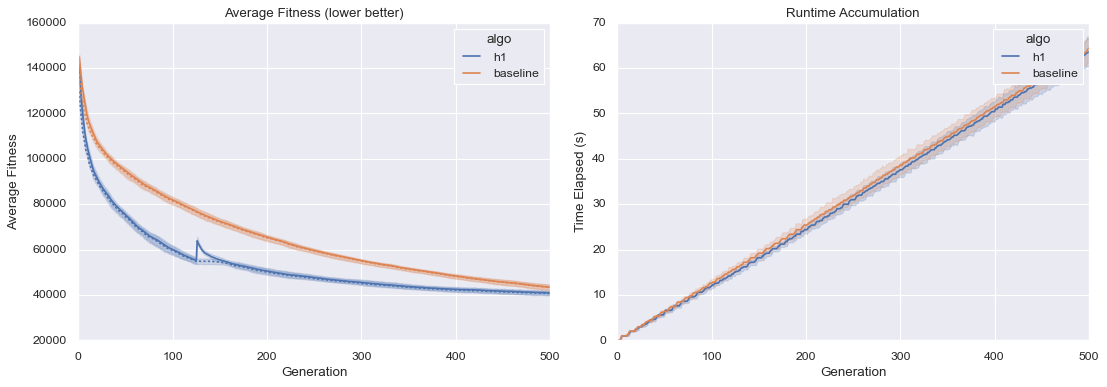

In [54]:

sns.set_theme(style="darkgrid")

# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------------------------------
# PLOT 1: Average Fitness over Generations
# ----------------------------------------------------
sns.lineplot(
    data=df, 
    x="num-generations", 
    y="avg-fitness", 
    hue="algo",       # Separates lines and colors by algorithm type
    errorbar="ci",         # "ci" for 95% Confidence Interval, or "sd" for Standard Deviation
    ax=axes[0]
)
# Also plot best fitness (Dashed lines to distinguish from Average)
sns.lineplot(
    data=df,
    x="num-generations",
    y="best-fitness",
    hue="algo",
    errorbar="ci",
    ax=axes[0],
    style="algo",  # Forces different line styles per algo...
    dashes=[(2, 2)]
    * len(df["algo"].unique()),  # ...but we override them all to be dashed (2pt dash, 2pt space)
    legend=False,  # Turns off duplicate legend
)
axes[0].set_title("Average Fitness (lower better)")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Average Fitness")


# ----------------------------------------------------
# PLOT 2: Runtime over Generations
# ----------------------------------------------------
sns.lineplot(
    data=df, 
    x="num-generations", 
    y="time-elapsed", 
    hue="algo", 
    errorbar="ci", 
    ax=axes[1]
)
axes[1].set_title("Runtime Accumulation")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Time Elapsed (s)")

# Adjust layout and show
plt.tight_layout()
plt.show()

In [48]:
# Save data
# df.to_pickle("0605_evolution_results.pkl")
df = pd.read_pickle("0604_evolution_results.pkl")

In [42]:
import glob, os, re
def show_progress_over_time(folder, grid=(5,4)):
    # seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )
    
    folder_path = f"{folder}/*.png"
    files = glob.glob(folder_path)
    # print(files)


    # 2. Define a sorting key function
    def get_trailing_number(filename):
        # Search for digits right before the .png extension
        match = re.search(r"(\d+)\.png$", filename)
        # Convert to integer so 050 comes before 500 numerically
        return int(match.group(1)) if match else 0


    # 3. Sort the list using our custom key
    ordered_files = sorted(files, key=get_trailing_number)

    # Print the result to verify
    for f in ordered_files:
        print(os.path.basename(f))

    img_arr = [Image.open(i) for i in ordered_files]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # plt.show()

intermediate_0_100_500__00050.png
intermediate_0_100_500__00100.png
intermediate_0_100_500__00150.png
intermediate_0_100_500__00200.png
intermediate_0_100_500__00250.png
intermediate_0_100_500__00300.png
intermediate_0_100_500__00350.png
intermediate_0_100_500__00400.png
intermediate_0_100_500__00450.png
intermediate_0_100_500__00500.png


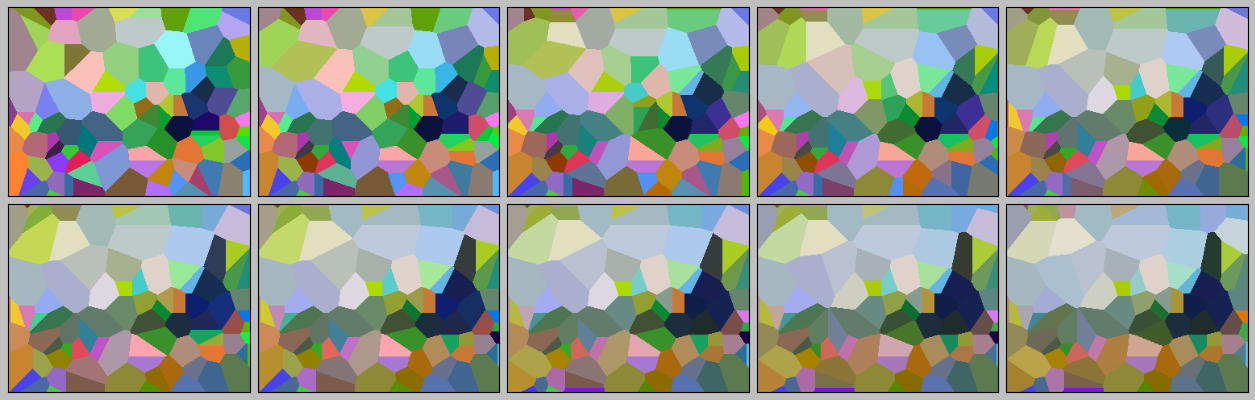

In [45]:
show_progress_over_time("./img/h1/0/",grid=(2,5))

intermediate_0_40_500_0-40_0.25-100_00050.png
intermediate_0_40_500_0-40_0.25-100_00100.png
intermediate_0_100_500_0-40_0.25-100_00150.png
intermediate_0_100_500_0-40_0.25-100_00200.png
intermediate_0_100_500_0-40_0.25-100_00250.png
intermediate_0_100_500_0-40_0.25-100_00300.png
intermediate_0_100_500_0-40_0.25-100_00350.png
intermediate_0_100_500_0-40_0.25-100_00400.png
intermediate_0_100_500_0-40_0.25-100_00450.png
intermediate_0_100_500_0-40_0.25-100_00500.png


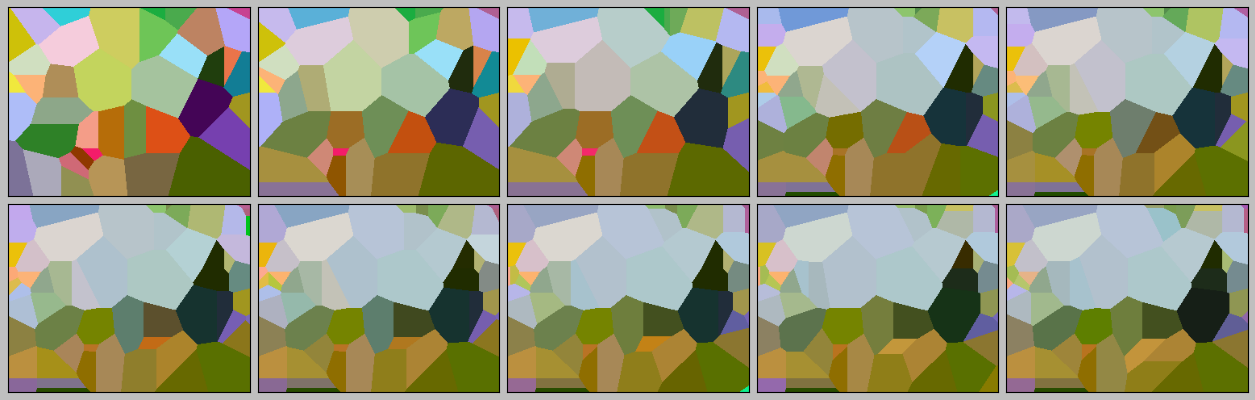

In [44]:
show_progress_over_time("./img/h1/5/",grid=(2,5))